In [1]:
from typing import List, Union, Tuple

import numpy as np
import cv2
import matplotlib.pyplot as plt


### Utils

In [2]:
def show_images(
    images : Union[np.ndarray, List[np.ndarray]], 
    titles : Union[str, List[str]] = '', 
    ncols  : int = 3, 
    figsize: Tuple[int, int] = (15, 10)
) -> None:
    """
    Hiển thị một hoặc nhiều hình ảnh dưới dạng lưới (Grid) chuyên nghiệp trong Jupyter Notebook.
    
    Parameters:
    -----------
    images : Một ảnh (np.ndarray) hoặc một danh sách các ảnh [img1, img2, ...].
    titles : Một tiêu đề hoặc danh sách tiêu đề tương ứng với từng ảnh.
    ncols  : Số cột tối đa của lưới hiển thị (Mặc định: 3).
    figsize: Kích thước tổng thể của khung hiển thị (Rộng, Cao).
    """
    # Chuẩn hóa đầu vào nếu người dùng chỉ truyền vào 1 ảnh đơn lẻ
    if isinstance(images, np.ndarray):
        images = [images]
    if isinstance(titles, str):
        titles = [titles]
        
    n_images = len(images)
    
    # Tính toán số hàng cần thiết dựa trên số ảnh và số cột
    nrows = (n_images + ncols - 1) // ncols
    
    # Tạo khung chứa các ảnh (chỉ tạo đúng số lượng hàng/cột cần thiết)
    fig, axes = plt.subplots(
        nrows=nrows, 
        ncols=ncols if n_images >= ncols else n_images, 
        figsize=figsize
    )
    
    # Phẳng hóa mảng axes để dễ lặp qua bằng vòng lặp for
    if n_images == 1:
        axes = np.array([axes])
    else:
        axes = np.array(axes).flatten()
        
    for i in range(len(axes)):
        ax = axes[i]
        
        if i < n_images:
            img = images[i]
            
            # 1. Xử lý và chuyển đổi hệ màu từ BGR sang RGB
            if len(img.shape) == 3 and img.shape[2] == 3:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img_rgb)
            else:
                # Trường hợp ảnh xám (Grayscale)
                ax.imshow(img, cmap='gray')
                
            # 2. Thêm tiêu đề nếu có
            if titles and i < len(titles):
                ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=8)
                
            # 3. Ẩn trục tọa độ để giao diện gọn gàng, chuyên nghiệp
            ax.axis('off')
        else:
            # Ẩn các ô lưới thừa nếu số lượng ảnh không lấp đầy grid
            ax.axis('off')
            
    plt.tight_layout()
    plt.show()

In [3]:
def sobel_grad(img):
    kernel_x = np.array([ [-1.0, 0.0, 1.0],
                          [-2.0, 0.0, 2.0],
                          [-1.0, 0.0, 1.0]], dtype=np.float64)
    kernel_y = np.array([[-1.0, -2.0, -1.0],
                         [ 0.0,  0.0,  0.0],
                         [ 1.0,  2.0,  1.0]], dtype=np.float64)
    gx = cv2.filter2D(img.astype(np.float64), -1, kernel_x)
    gy = cv2.filter2D(img.astype(np.float64), -1, kernel_y)
    return gx, gy
    
def clean_edges(img, sigma):
    return cv2.GaussianBlur(img, (0,0), sigma) if sigma > 0 else img

def grad_mag_orient(gx, gy):
    return np.hypot(gx, gy), np.degrees(np.arctan2(gy, gx))

def non_max_suppression(mag, ori_deg):
    H, W = mag.shape
    out = np.zeros_like(mag)
    a = ori_deg % 180
    for i in range(1, H-1):
        for j in range(1, W-1):
            d = a[i, j]
            if d < 22.5 or d >= 157.5:
                p, q = mag[i, j-1], mag[i, j+1]
            elif d < 67.5:                
                p, q = mag[i-1, j-1], mag[i+1, j+1]
            elif d < 112.5:
                p, q = mag[i-1, j], mag[i+1, j]
            else:
                p, q = mag[i+1, j-1], mag[i-1, j+1]
            if mag[i, j] >= p and mag[i, j] >= q:
                out[i, j] = mag[i, j]
    return out

def hysteresis(nms, low, high):
    strong = nms >= high
    weak   = (nms >= low) & (nms < high)
    cand   = (strong | weak).astype(np.uint8)
    n, lab = cv2.connectedComponents(cand, connectivity=8)
    keep   = set(np.unique(lab[strong]))
    return np.where(np.isin(lab, list(keep)) & (lab > 0), 255, 0).astype(np.uint8)

### Pipeline

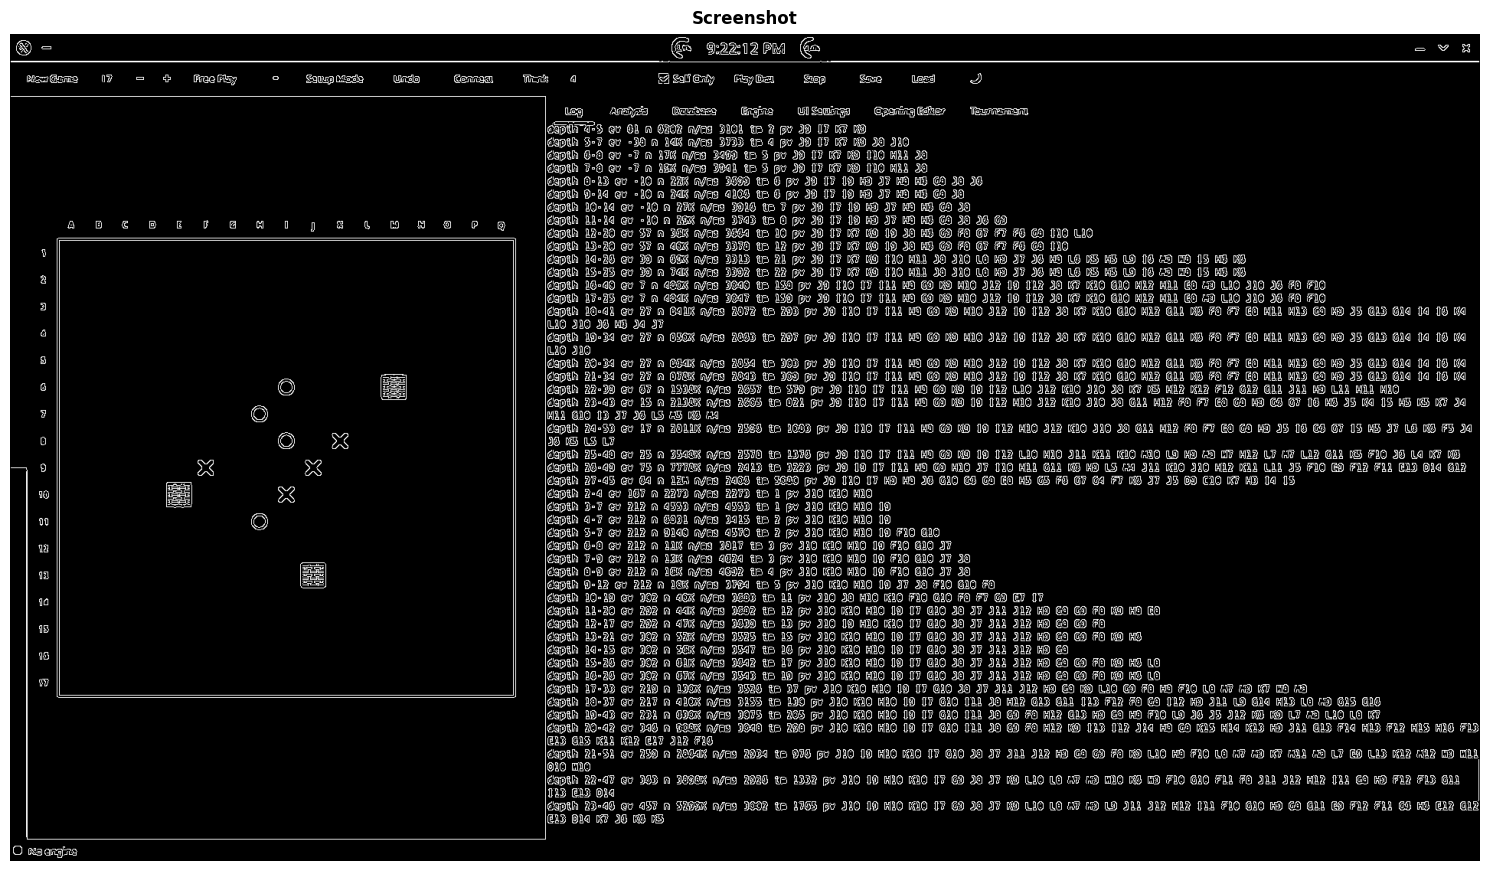

In [4]:
img = cv2.imread('screenshot.png')
assert img is not None, 'Could not load image'

img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gx, gy = sobel_grad(clean_edges(img, 1.0))
nms = non_max_suppression(*grad_mag_orient(gx, gy))
hys = hysteresis(nms, 40, 80)

show_images(hys, 'Screenshot')

### Main